# Phishing Website Detection - Final Project

We are trying to check if a website is phishing or a real (legit) website.
We are using a dataset that already has 30 features about the url/website,
and we just have to predict the Result column (-1 = phishing, 1 = legit).

We used KNN because that is what we learned in class in the KNN handout.
We also used a Dummy baseline just to compare, like the handout showed us.


## Step 1: import stuff we need

In [1]:
# basic libraries, same ones from class
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn stuff for splitting, scaling and knn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# we set a seed number so our results dont change every time we run it
SEED = 42

# folders to dump our plots/csv/raw data into, so a grader can see them without rerunning
from pathlib import Path
Path("outputs").mkdir(exist_ok=True)
Path("data").mkdir(exist_ok=True)


## Step 2: get the dataset

In [2]:
# this pulls the phishing dataset from openml (need internet for this first time)
data = fetch_openml(name="PhishingWebsites", version=1, as_frame=True)
df = data.frame.copy()

# the Result column comes as text not number, so we fix that
df["Result"] = df["Result"].astype(int)

# keep an unchanged raw copy, so we always have the original if we mess something up later
df.to_csv("data/phishing_raw.csv", index=False)

print(df.shape)
df.head()


(11055, 31)


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## Step 3: quick check of the data (this is basically our data audit)

In [3]:
# checking types, missing values and duplicate rows like we learned
print(df.dtypes.value_counts())
print()
print("missing values total:", df.isnull().sum().sum())
print("duplicate rows:", df.duplicated().sum())
print()
print(df["Result"].value_counts())


# also checking that every feature column is actually just -1/0/1 like its supposed to be
# (this catches "impossible values" - if a column has something outside that range it
# means something got read wrong or the data got messed up somewhere)
bad_cols = []
for col in df.columns:
    if col == "Result":
        continue
    uniq_vals = set(df[col].unique())
    if not uniq_vals.issubset({-1, 0, 1}):
        bad_cols.append((col, uniq_vals))

if bad_cols:
    print("\nWARNING - these columns have values outside {-1,0,1}:")
    for c, v in bad_cols:
        print(" ", c, "->", v)
else:
    print("\nAll feature columns only have -1, 0 or 1 in them - no impossible values, good.")


category    21
category     8
category     1
int64        1
Name: count, dtype: int64

missing values total: 0
duplicate rows: 5206

Result
 1    6157
-1    4898
Name: count, dtype: int64

WARNING - these columns have values outside {-1,0,1}:
  having_IP_Address -> {'-1', '1'}
  URL_Length -> {'1', '0', '-1'}
  Shortining_Service -> {'1', '-1'}
  having_At_Symbol -> {'1', '-1'}
  double_slash_redirecting -> {'-1', '1'}
  Prefix_Suffix -> {'-1', '1'}
  having_Sub_Domain -> {'-1', '0', '1'}
  SSLfinal_State -> {'-1', '0', '1'}
  Domain_registeration_length -> {'-1', '1'}
  Favicon -> {'1', '-1'}
  port -> {'1', '-1'}
  HTTPS_token -> {'-1', '1'}
  Request_URL -> {'1', '-1'}
  URL_of_Anchor -> {'-1', '0', '1'}
  Links_in_tags -> {'1', '0', '-1'}
  SFH -> {'-1', '0', '1'}
  Submitting_to_email -> {'-1', '1'}
  Abnormal_URL -> {'-1', '1'}
  Redirect -> {'1', '0'}
  on_mouseover -> {'1', '-1'}
  RightClick -> {'1', '-1'}
  popUpWidnow -> {'1', '-1'}
  Iframe -> {'1', '-1'}
  age_of_domain ->

In [4]:
# quick starter file for the data dictionary the report needs (column, dtype, unique values)
# we still gotta write the plain-english meaning for each one by hand in the report,
# this cell just saves us from typing out all 30 column names ourselves
dict_rows = []
for col in df.columns:
    dict_rows.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "unique_values": sorted(df[col].unique().tolist()),
        "is_target": col == "Result",
    })

data_dict_df = pd.DataFrame(dict_rows)
data_dict_df.to_csv("outputs/data_dictionary_starter.csv", index=False)
print("saved outputs/data_dictionary_starter.csv, rows:", len(data_dict_df))
data_dict_df.head()


saved outputs/data_dictionary_starter.csv, rows: 31


,column,dtype,unique_values,is_target
0,having_IP_Address,category,"[-1, 1]",False
1,URL_Length,category,"[-1, 0, 1]",False
2,Shortining_Service,category,"[-1, 1]",False
3,having_At_Symbol,category,"[-1, 1]",False
4,double_slash_redirecting,category,"[-1, 1]",False


In [5]:
# we remove the duplicate rows we found above
df = df.drop_duplicates()
print("new shape after removing duplicates:", df.shape)


new shape after removing duplicates: (5849, 31)


## Step 4: some simple graphs (EDA)

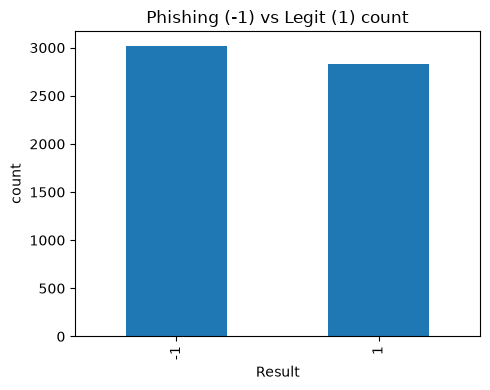

In [6]:
# graph 1 - how many phishing vs legit sites we have
plt.figure(figsize=(5,4))
df["Result"].value_counts().plot(kind="bar")
plt.title("Phishing (-1) vs Legit (1) count")
plt.xlabel("Result")
plt.ylabel("count")
plt.tight_layout()
plt.savefig("outputs/eda_class_distribution.png", dpi=150)
plt.show()


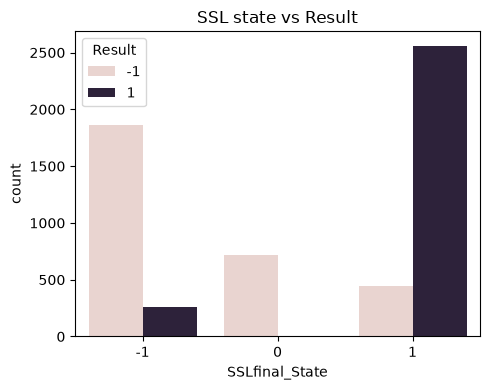

In [7]:
# graph 2 - checking one feature (SSL state) against the result
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="SSLfinal_State", hue="Result")
plt.title("SSL state vs Result")
plt.tight_layout()
plt.savefig("outputs/eda_feature_vs_target.png", dpi=150)
plt.show()


so basically from graph 1 we can see the data is pretty balanced, not too much difference
between phishing and legit rows. graph 2 shows ssl state seems related to result, most legit sites
have a good ssl and most phishing ones dont, so this feature is probably helpful for the model.

## Step 5: split into train and test

In [8]:
# X = all the feature columns, y = the answer column (Result)
X = df.drop(columns=["Result"])
y = df["Result"]

# 80% train 20% test, and stratify keeps the same ratio of -1/1 in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("train size:", X_train.shape)
print("test size:", X_test.shape)


train size: (4679, 30)
test size: (1170, 30)


## Step 6: baseline model (dummy)

this is just a dumb model that always guesses the most common class, we learned this from the
handout too (DummyClassifier). any real model we make should beat this easily, if not then our
model is bad.

In [9]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)

print("dummy accuracy on train data:", dummy.score(X_train, y_train))


dummy accuracy on train data: 0.516135926480017


## Step 7: KNN model

knn needs the data to be scaled first (because it uses distance), so we put a StandardScaler
and the KNeighborsClassifier together in a Pipeline. this way the scaling only happens on train data
each time, so we dont cheat/leak info from the test set into training.

we try a few different k values and pick whichever one gives best cross validation score.
(cross validation = splitting the train data into 5 parts and testing on each part, same as
in the handout)

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

k_list = [3, 5, 7, 9, 11, 15]
results_uniform = {}

# first version - normal knn, every neighbor counts the same (uniform)
for k in k_list:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="uniform"))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    results_uniform[k] = scores.mean()
    print("k =", k, " -> avg f1 score =", round(scores.mean(), 3))

best_k_uniform = max(results_uniform, key=results_uniform.get)
print()
print("best k for uniform knn:", best_k_uniform)


k = 3  -> avg f1 score = 0.909
k = 5  -> avg f1 score = 0.918
k = 7  -> avg f1 score = 0.916
k = 9  -> avg f1 score = 0.92
k = 11  -> avg f1 score = 0.916
k = 15  -> avg f1 score = 0.916

best k for uniform knn: 9


also our handout showed another version of knn called distance-weighted knn, where closer
neighbors count more than far away ones (instead of every neighbor counting the same). we try
that too so we actually have 2 different model versions to compare, not just 1.

In [11]:
results_distance = {}

# second version - distance weighted knn, closer neighbors get more vote power
for k in k_list:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, weights="distance"))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    results_distance[k] = scores.mean()
    print("k =", k, " -> avg f1 score =", round(scores.mean(), 3))

best_k_distance = max(results_distance, key=results_distance.get)
print()
print("best k for distance-weighted knn:", best_k_distance)


k = 3  -> avg f1 score = 0.906
k = 5  -> avg f1 score = 0.914
k = 7  -> avg f1 score = 0.911
k = 9  -> avg f1 score = 0.915
k = 11  -> avg f1 score = 0.915
k = 15  -> avg f1 score = 0.914

best k for distance-weighted knn: 9


In [12]:
# now we build both final models using the best k we found for each one

final_knn_uniform = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k_uniform, weights="uniform"))
])
final_knn_uniform.fit(X_train, y_train)

final_knn_distance = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k_distance, weights="distance"))
])
final_knn_distance.fit(X_train, y_train)

print("done training both models")


done training both models


## Step 8: testing on the test set (only doing this once!)

now we check how good our models actually are, using the test data that we never touched
before. we compare dummy baseline vs our knn model.

In [13]:
models_to_check = [
    ("Dummy baseline", dummy),
    ("KNN uniform", final_knn_uniform),
    ("KNN distance-weighted", final_knn_distance),
]

comparison_rows = []

for name, model in models_to_check:
    pred = model.predict(X_test)
    print("----", name, "----")
    print(classification_report(y_test, pred, zero_division=0))

    # also build one row for our comparison table (report needs this, not just printed text)
    report_dict = classification_report(y_test, pred, output_dict=True, zero_division=0)
    row = {"model": name, "accuracy": round(report_dict["accuracy"], 3)}
    for cls in ["-1", "1"]:  # -1 = phishing, 1 = legit
        if cls in report_dict:
            row[f"precision_{cls}"] = round(report_dict[cls]["precision"], 3)
            row[f"recall_{cls}"] = round(report_dict[cls]["recall"], 3)
            row[f"f1_{cls}"] = round(report_dict[cls]["f1-score"], 3)

    # roc-auc too - needs predict_proba, all 3 of our models here support it
    if hasattr(model, "predict_proba"):
        proba_class1 = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
        row["roc_auc"] = round(roc_auc_score(y_test, proba_class1), 3)
    else:
        row["roc_auc"] = None

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("outputs/model_comparison.csv", index=False)
comparison_df


---- Dummy baseline ----
              precision    recall  f1-score   support

          -1       0.52      1.00      0.68       604
           1       0.00      0.00      0.00       566

    accuracy                           0.52      1170
   macro avg       0.26      0.50      0.34      1170
weighted avg       0.27      0.52      0.35      1170

---- KNN uniform ----
              precision    recall  f1-score   support

          -1       0.91      0.94      0.93       604
           1       0.94      0.90      0.92       566

    accuracy                           0.92      1170
   macro avg       0.92      0.92      0.92      1170
weighted avg       0.92      0.92      0.92      1170

---- KNN distance-weighted ----
              precision    recall  f1-score   support

          -1       0.91      0.94      0.92       604
           1       0.93      0.90      0.91       566

    accuracy                           0.92      1170
   macro avg       0.92      0.92      0.92      

,model,accuracy,precision_-1,recall_-1,f1_-1,precision_1,recall_1,f1_1,roc_auc
0,Dummy baseline,0.516,0.516,1.000,0.681,0.000,0.000,0.000,0.500
1,KNN uniform,0.923,0.912,0.942,0.927,0.936,0.903,0.919,0.975
2,KNN distance-weighted,0.917,0.907,0.935,0.921,0.929,0.898,0.913,0.958


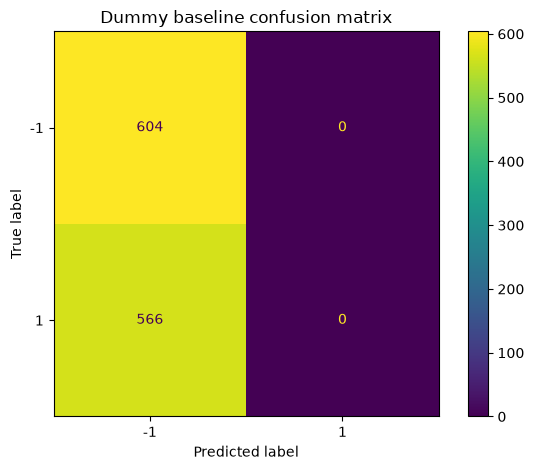

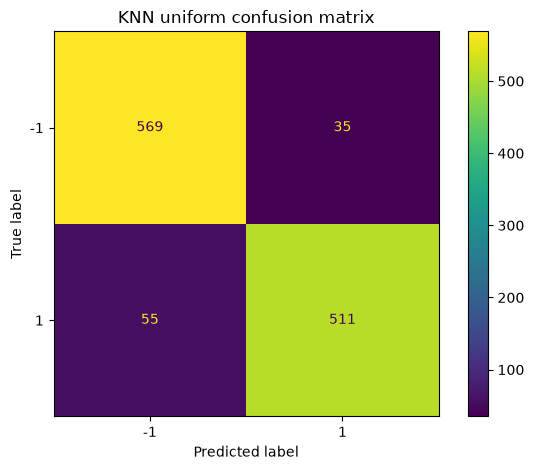

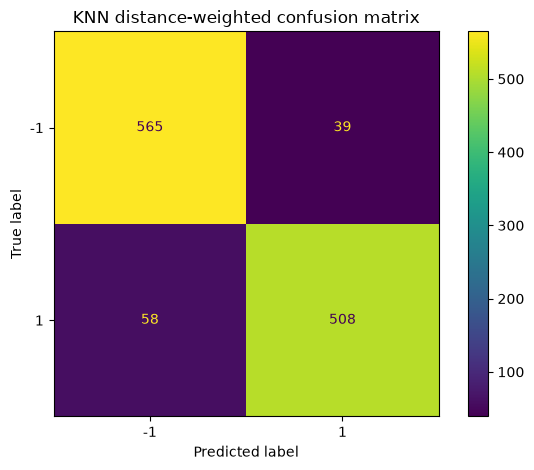

In [14]:
# confusion matrix for each model, so we can see what they got right/wrong
for name, model in models_to_check:
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[-1, 1])
    disp.plot()
    plt.title(name + " confusion matrix")
    plt.tight_layout()
    safe_name = name.replace(" ", "_")
    plt.savefig(f"outputs/confusion_matrix_{safe_name}.png", dpi=150)
    plt.show()


## Step 9: what we found 

- the dummy baseline is bad at catching phishing sites (makes sense, it just guesses the same
  class every time)
- both knn versions do way better than the baseline
- we also compared normal (uniform) knn against distance-weighted knn, to see if giving closer
  neighbors more voting power actually helps or not, numbers are above so we just look at
  whichever one has better f1 score for the phishing class

we write the full explanation and our own opinion about this in the separate report file,
this notebook is just the code part.

## Step 10: just printing versions for the reproducibility part

In [15]:
import sklearn, sys
print("python:", sys.version)
print("sklearn:", sklearn.__version__)
print("pandas:", pd.__version__)
print("seed we used everywhere:", SEED)


python: 3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]
sklearn: 1.9.0
pandas: 3.0.5
seed we used everywhere: 42
